<a href="https://colab.research.google.com/github/MAYANK181105/Project1/blob/main/Mayank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seasonal Agriculture Performance Analysis

Major Data Analytics Project

Domain: Agriculture

Project Theme: Seasonal Agriculture Performance

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

2. Project Objectives

Understand the structure and quality of the agricultural dataset.

Clean and prepare the data for analysis.

Explore seasonal patterns in the dataset.

Perform descriptive and statistical analysis.

Investigate relationships among relevant variables.

Compare agricultural performance across seasons and other meaningful groups.

Use appropriate univariate, bivariate and multivariate visualizations.

Identify significant findings from the data.

Develop evidence-based insights and recommendations.

2. Project Objectives

Understand the structure and quality of the agricultural dataset.

Clean and prepare the data for analysis.

Explore seasonal patterns in the dataset.

Perform descriptive and statistical analysis.

Investigate relationships among relevant variables.

Compare agricultural performance across seasons and other meaningful groups.

Use appropriate univariate, bivariate and multivariate visualizations.

Identify significant findings from the data.

Develop evidence-based insights and recommendations.

3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
data=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
season_summary = data.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR', 'Total_Cost_INR']
].agg(['mean', 'median', 'std'])
season_summary

Yield_Tonnes_Ha                   Production_Tonnes                     \
                  mean median        std              mean median         std   
Season                                                                          
Kharif        5.643973   1.95  14.419077         46.311192  13.24  135.704677   
Rabi          5.080498   1.66  12.825348         41.486712  11.08  121.904792   
Zaid          4.665942   1.45  11.317728         38.886111   9.97  112.000668   

           Profit_INR                            Revenue_INR            \
                 mean   median            std           mean    median   
Season                                                                   
Kharif  178914.647555  38808.0  611549.783883  710719.055649  520196.0   
Rabi     87689.470191  -3187.0  489901.254255  601526.048556  438156.0   
Zaid    -24804.824916 -62144.0  436356.747261  519171.904040  373700.5   

                      Total_Cost_INR                           
                  std           mean    median            std  
Season                                                         
Kharif  708710.370061  531804.408094  524840.0  298487.687038  
Rabi    584545.521423  513836.578365  506733.0  288386.891838  
Zaid    509524.546191  543976.728956  534833.0  297576.858682

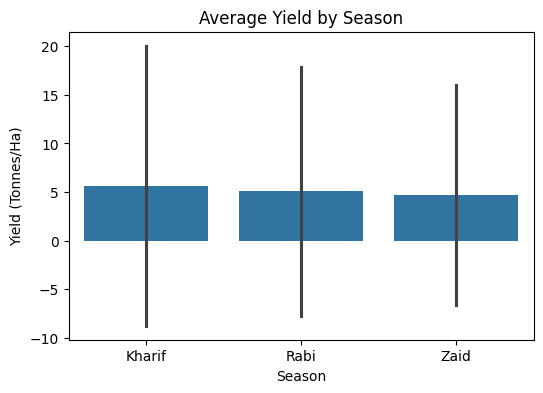

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=data, x='Season', y='Yield_Tonnes_Ha', estimator='mean', errorbar='sd')
plt.title('Average Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

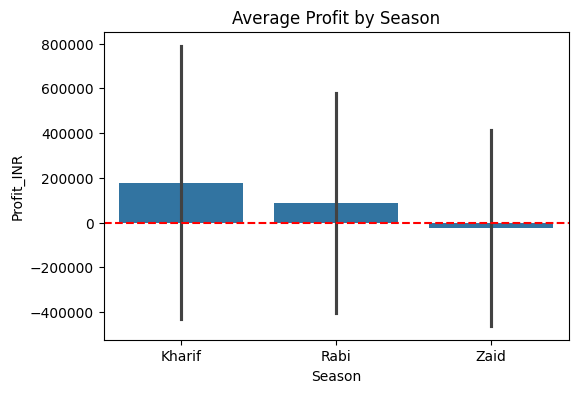

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=data, x='Season', y='Profit_INR', estimator='mean', errorbar='sd')
plt.title('Average Profit by Season')
plt.axhline(0, color='red', linestyle='--')
plt.show()

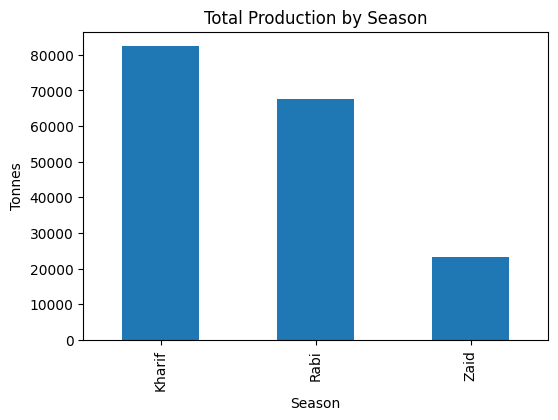

In [ ]:
data.groupby('Season')['Production_Tonnes'].sum().plot(kind='bar', figsize=(6,4), title='Total Production by Season')
plt.ylabel('Tonnes')
plt.show()

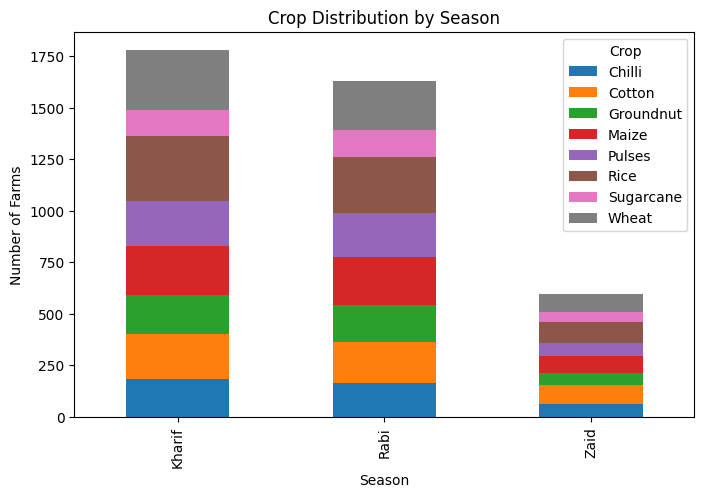

In [ ]:
pd.crosstab(data['Season'], data['Crop']).plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Crop Distribution by Season')
plt.ylabel('Number of Farms')
plt.show()

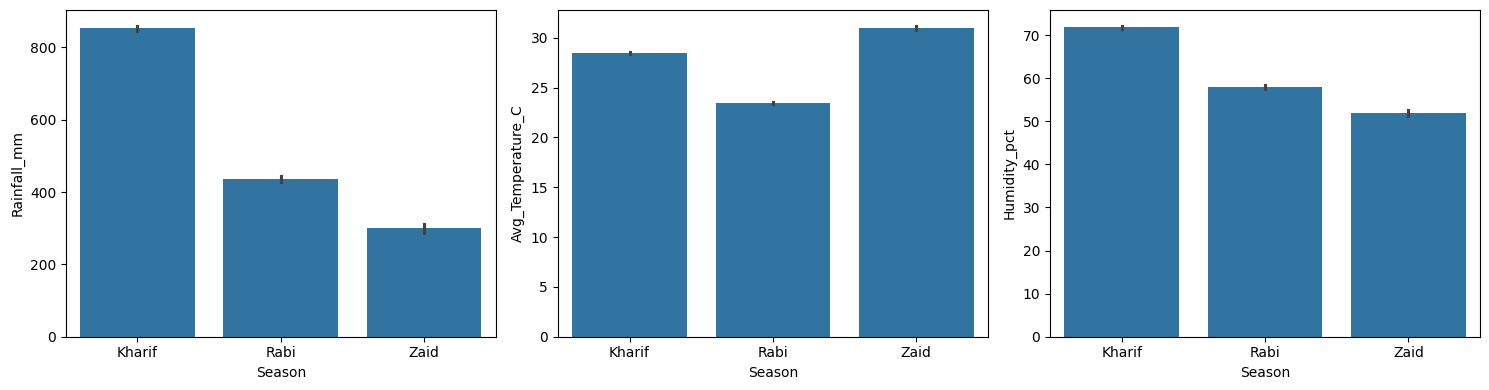

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.barplot(data=data, x='Season', y='Rainfall_mm', ax=axes[0])
sns.barplot(data=data, x='Season', y='Avg_Temperature_C', ax=axes[1])
sns.barplot(data=data, x='Season', y='Humidity_pct', ax=axes[2])
plt.tight_layout()
plt.show()

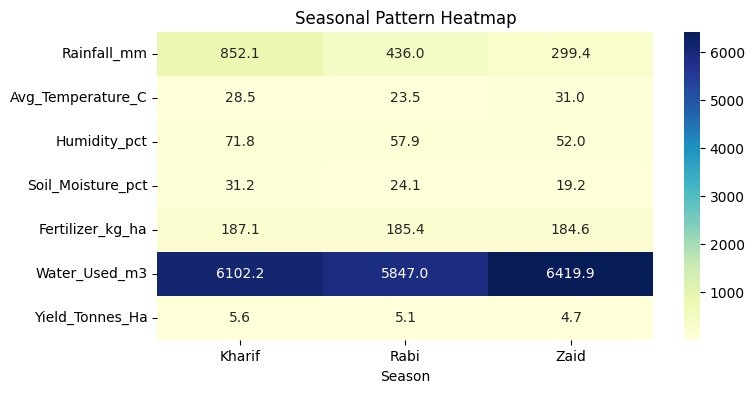

In [ ]:
season_avg = data.groupby('Season')[
    ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
     'Fertilizer_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha']
].mean()

plt.figure(figsize=(8,4))
sns.heatmap(season_avg.T, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Seasonal Pattern Heatmap')
plt.show()

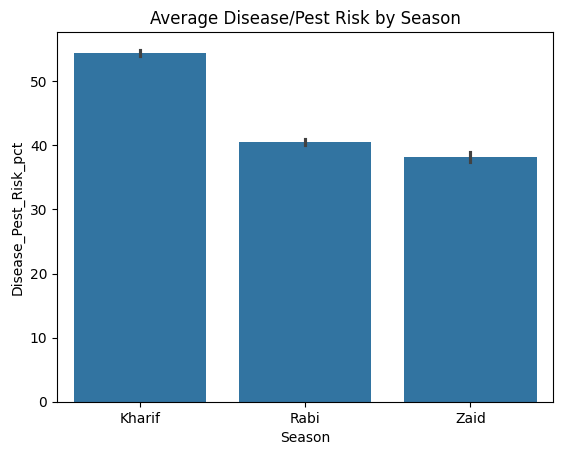

In [ ]:
sns.barplot(data=data, x='Season', y='Disease_Pest_Risk_pct', estimator='mean')
plt.title('Average Disease/Pest Risk by Season')
plt.show()

In [ ]:
numeric_cols = data.select_dtypes(include='number').columns.tolist()
season_means = data.groupby('Season')[numeric_cols].mean().round(2)
season_means

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,852.08,28.45,71.81,6.79,6.73,31.20,120.02,58.10,105.30,...,0.82,5.64,46.31,44850.91,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,436.00,23.49,57.89,7.59,6.67,24.05,120.40,57.31,103.93,...,0.83,5.08,41.49,44747.97,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,299.42,31.04,52.01,8.18,6.69,19.17,120.53,58.13,105.42,...,0.82,4.67,38.89,44212.03,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


In [ ]:
from scipy import stats

results = []
for col in numeric_cols:
    groups = [g[col].dropna() for _, g in data.groupby('Season')]
    f_stat, p_val = stats.f_oneway(*groups)
    results.append({'Characteristic': col, 'p_value': round(p_val, 4),
                     'Significant_Change': 'Yes' if p_val < 0.05 else 'No'})

results_df = pd.DataFrame(results).sort_values('p_value')
results_df

,Characteristic,p_value,Significant_Change
1,Rainfall_mm,0.0000,Yes
2,Avg_Temperature_C,0.0000,Yes
3,Humidity_pct,0.0000,Yes
4,Sunlight_Hours_Day,0.0000,Yes
6,Soil_Moisture_pct,0.0000,Yes
21,Disease_Pest_Risk_pct,0.0000,Yes
18,Profit_INR,0.0000,Yes
17,Revenue_INR,0.0000,Yes
20,Water_Efficiency_t_per_1000m3,0.0010,Yes
12,Seed_Quality_Score,0.0076,Yes


In [ ]:
season_range = season_means.max() - season_means.min()
season_pct_change = (season_range / season_means.mean() * 100).round(1)
season_pct_change.sort_values(ascending=False)

,0
Profit_INR,252.8
Rainfall_mm,104.4
Soil_Moisture_pct,48.5
Disease_Pest_Risk_pct,36.6
Humidity_pct,32.7
Revenue_INR,31.4
Water_Efficiency_t_per_1000m3,28.7
Avg_Temperature_C,27.3
Yield_Tonnes_Ha,18.9
Sunlight_Hours_Day,18.5


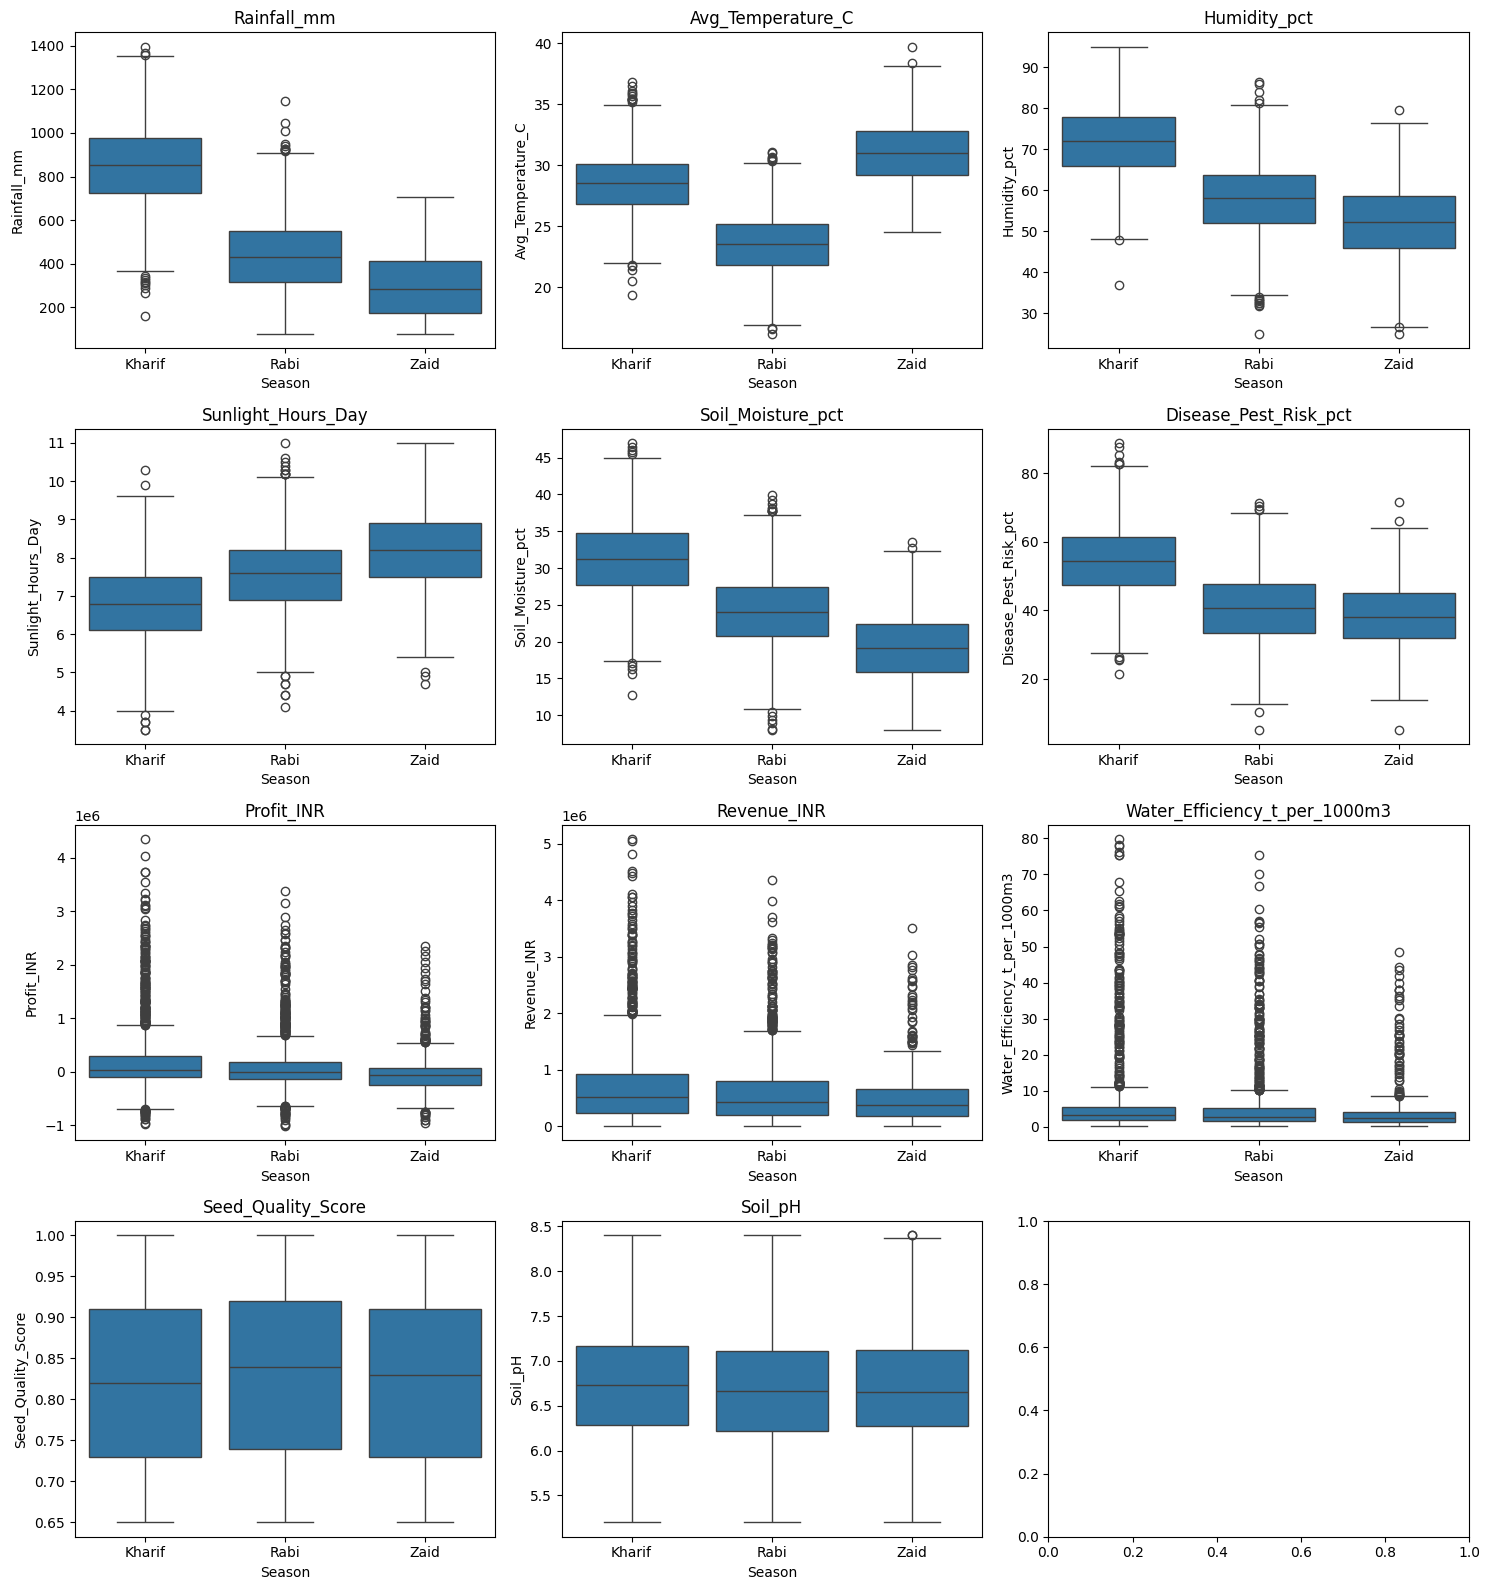

In [ ]:
sig_cols = results_df[results_df['Significant_Change']=='Yes']['Characteristic'].tolist()

fig, axes = plt.subplots(len(sig_cols)//3 + 1, 3, figsize=(15, 4*(len(sig_cols)//3 + 1)))
axes = axes.flatten()
for i, col in enumerate(sig_cols):
    sns.boxplot(data=data, x='Season', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

for col in ['Crop', 'Irrigation_Method']:
    contingency = pd.crosstab(data['Season'], data[col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2 p-value = {p:.4f} → {'Changes' if p<0.05 else 'No significant change'} by season")

Crop: chi2 p-value = 0.4550 → No significant change by season
Irrigation_Method: chi2 p-value = 0.7423 → No significant change by season


In [ ]:
crop_season = pd.crosstab(data['Season'], data['Crop'])
crop_season_pct = pd.crosstab(data['Season'], data['Crop'], normalize='index').round(3) * 100
print(crop_season)
print(crop_season_pct)

Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    10.4    12.1       10.8   13.2    12.4  17.7        7.0   16.4
Rabi      10.0    12.4       10.9   14.3    13.1  16.8        7.9   14.6
Zaid      10.8    15.5        9.1   14.1    10.4  17.2        8.6   14.3


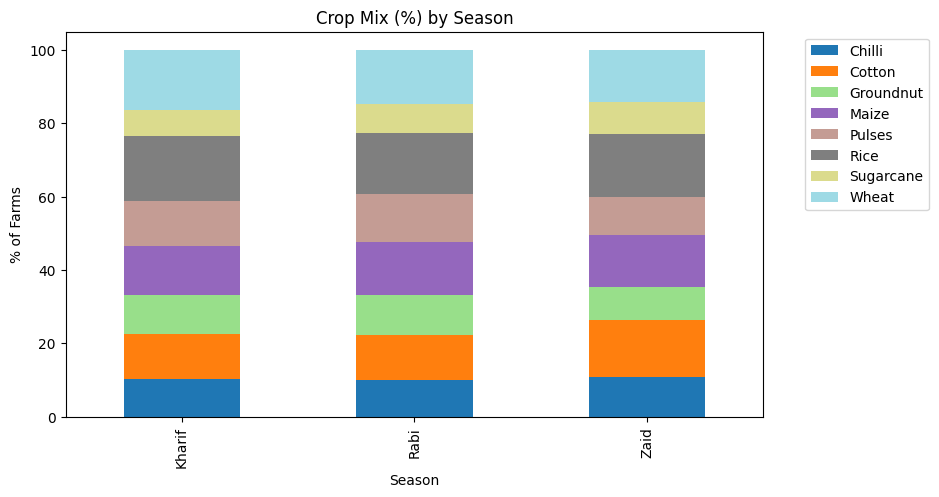

In [ ]:
crop_season_pct.plot(kind='bar', stacked=True, figsize=(9,5), colormap='tab20')
plt.title('Crop Mix (%) by Season')
plt.ylabel('% of Farms')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

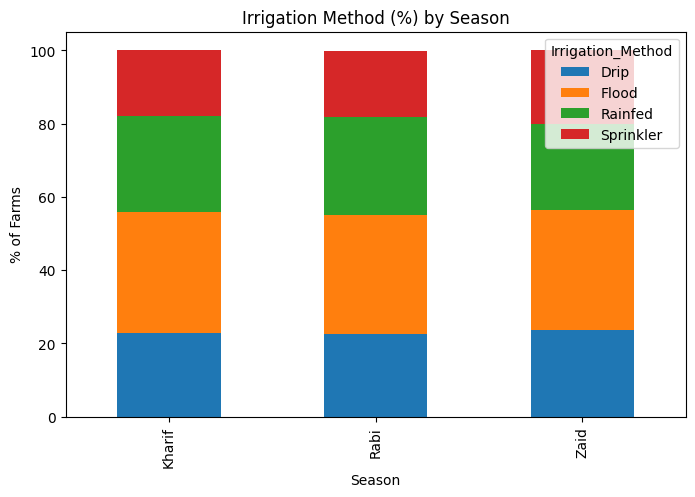

In [ ]:
irrigation_season = pd.crosstab(data['Season'], data['Irrigation_Method'], normalize='index').round(3) * 100
irrigation_season.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Irrigation Method (%) by Season')
plt.ylabel('% of Farms')
plt.show()

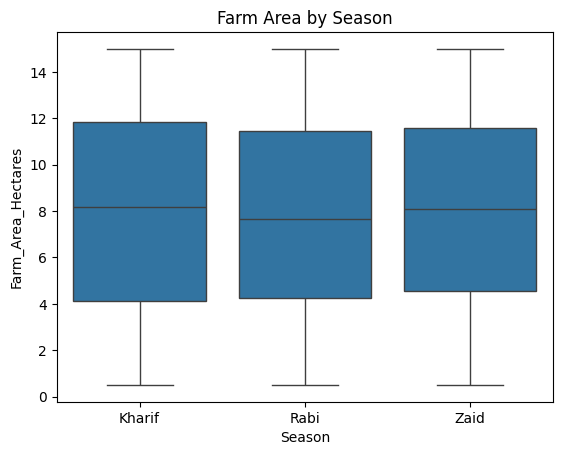

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,7.944924,4.282328,0.5,4.1100,8.180,11.825,15.00
Rabi,1627.0,7.752207,4.179402,0.5,4.2650,7.680,11.460,15.00
Zaid,594.0,8.091246,4.162594,0.5,4.5625,8.085,11.595,14.99


In [ ]:
sns.boxplot(data=data, x='Season', y='Farm_Area_Hectares')
plt.title('Farm Area by Season')
plt.show()

data.groupby('Season')['Farm_Area_Hectares'].describe()

In [ ]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(crop_season)
print(f"Chi-square p-value: {p:.4f}")

Chi-square p-value: 0.4550


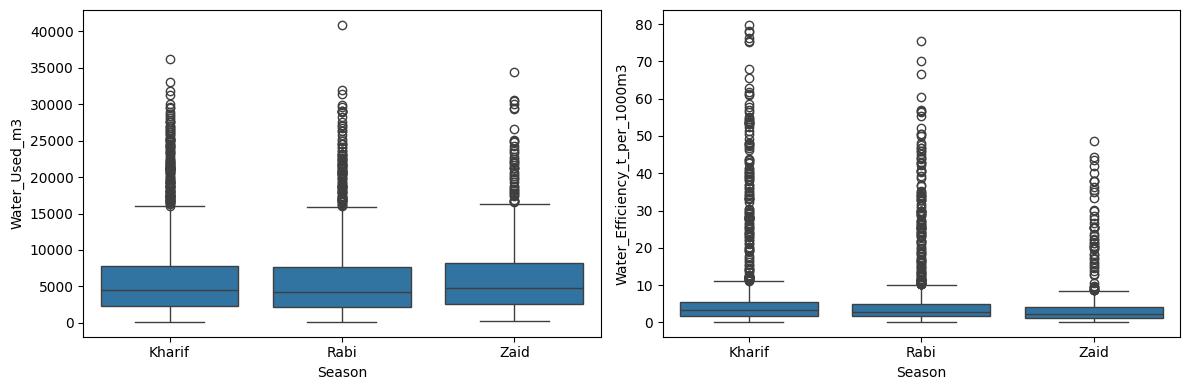

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=data, x='Season', y='Water_Used_m3', ax=axes[0])
sns.boxplot(data=data, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1])
plt.tight_layout()
plt.show()

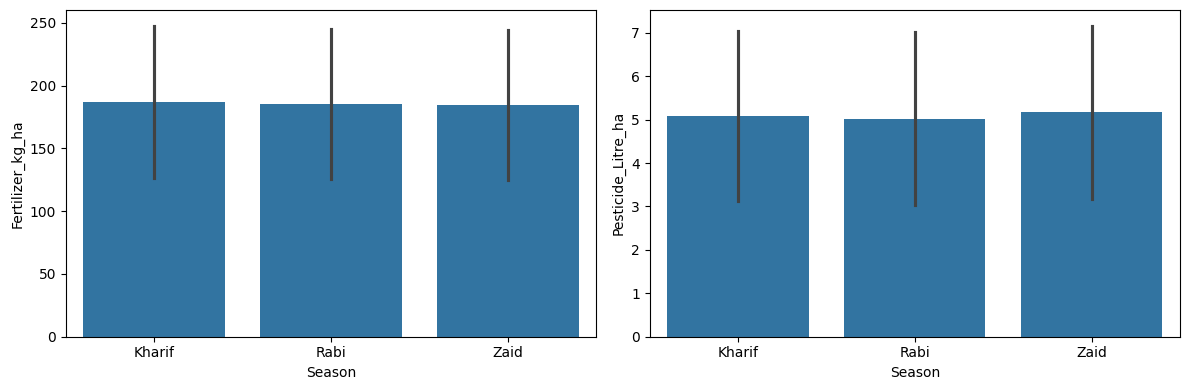

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=data, x='Season', y='Fertilizer_kg_ha', estimator='mean', errorbar='sd', ax=axes[0])
sns.barplot(data=data, x='Season', y='Pesticide_Litre_ha', estimator='mean', errorbar='sd', ax=axes[1])
plt.tight_layout()
plt.show()

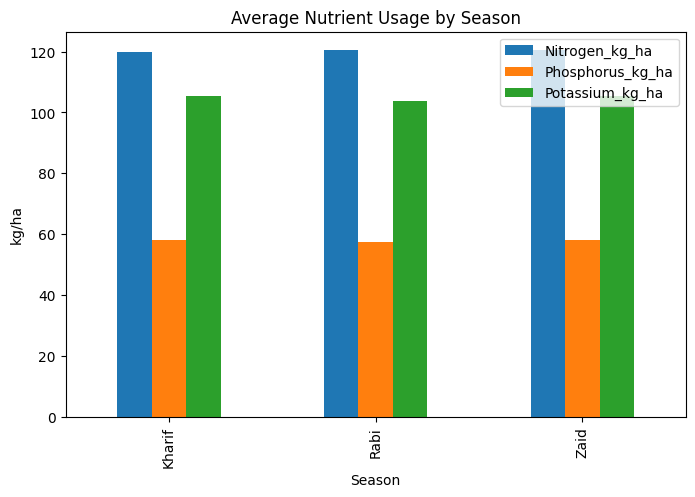

In [ ]:
data.groupby('Season')[['Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha']].mean().plot(kind='bar', figsize=(8,5))
plt.title('Average Nutrient Usage by Season')
plt.ylabel('kg/ha')
plt.show()

In [ ]:
data.groupby('Season')[['Water_Used_m3','Fertilizer_kg_ha','Pesticide_Litre_ha']].sum()

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,10855816,332811.7,9036.87
Rabi,9513048,301657.3,8175.17
Zaid,3813417,109675.0,3071.70


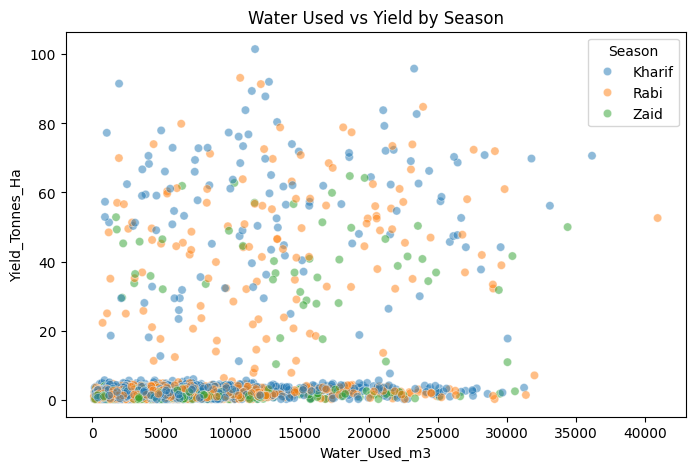

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Water_Used_m3', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5)
plt.title('Water Used vs Yield by Season')
plt.show()

In [ ]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
perf_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']

corr_matrix = data[env_cols + perf_cols].corr()
corr_matrix.loc[env_cols, perf_cols].round(3)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Rainfall_mm,0.031,0.025,0.108
Avg_Temperature_C,0.009,0.007,0.009
Humidity_pct,0.011,0.004,0.064
Sunlight_Hours_Day,-0.015,-0.024,-0.055
Soil_pH,-0.021,-0.013,-0.013
Soil_Moisture_pct,0.010,0.005,0.092


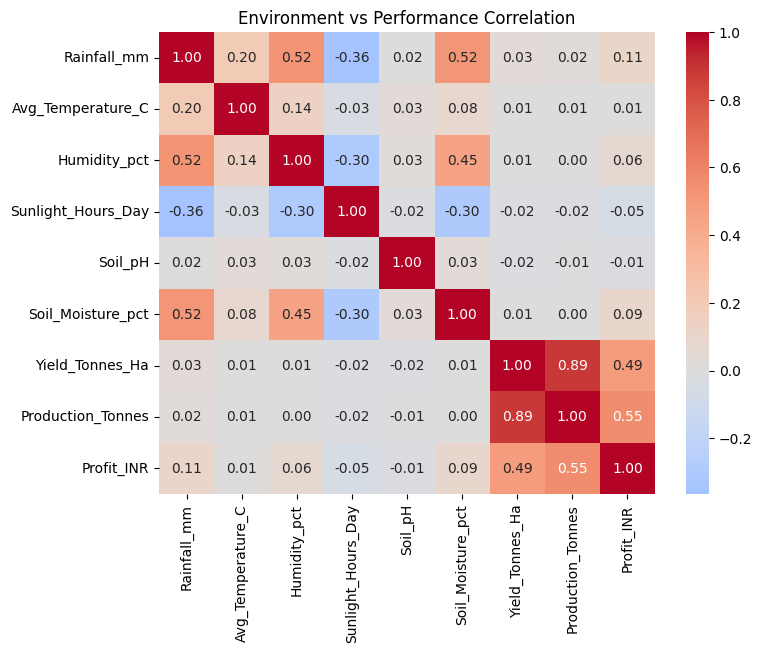

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data[env_cols + perf_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Environment vs Performance Correlation')
plt.show()

In [ ]:
for season in data['Season'].unique():
    sub = data[data['Season']==season]
    print(f"\n--- {season} ---")
    print(sub[env_cols + ['Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').round(3))


--- Kharif ---
Rainfall_mm          -0.019
Avg_Temperature_C    -0.011
Humidity_pct         -0.017
Sunlight_Hours_Day   -0.021
Soil_pH              -0.026
Soil_Moisture_pct     0.001
Name: Yield_Tonnes_Ha, dtype: float64

--- Rabi ---
Rainfall_mm           0.042
Avg_Temperature_C     0.054
Humidity_pct          0.018
Sunlight_Hours_Day    0.009
Soil_pH              -0.016
Soil_Moisture_pct    -0.021
Name: Yield_Tonnes_Ha, dtype: float64

--- Zaid ---
Rainfall_mm           0.049
Avg_Temperature_C    -0.045
Humidity_pct         -0.061
Sunlight_Hours_Day    0.022
Soil_pH              -0.024
Soil_Moisture_pct    -0.028
Name: Yield_Tonnes_Ha, dtype: float64


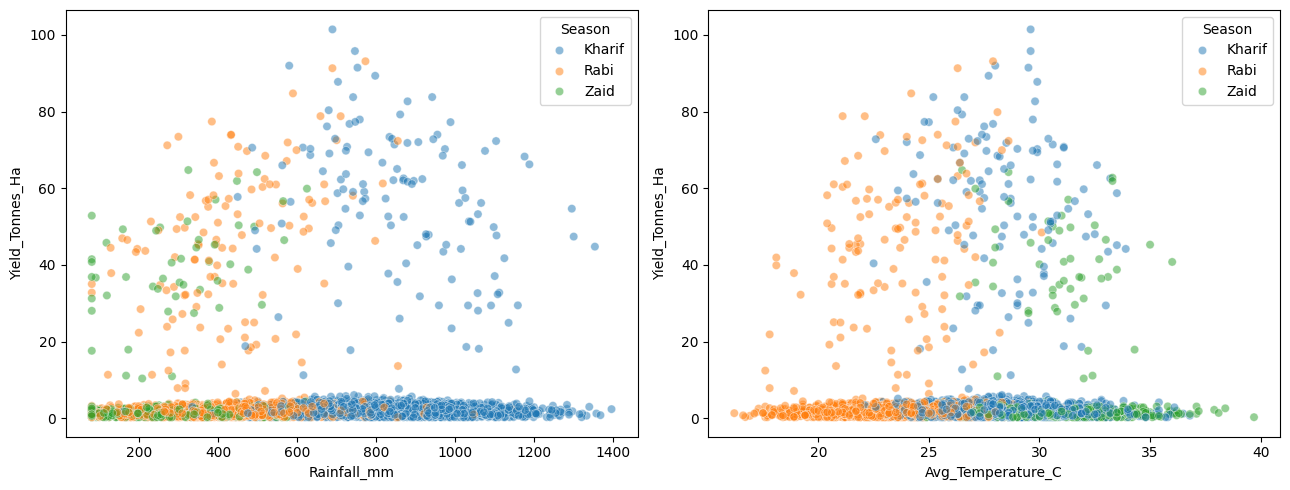

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=data, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[0])
sns.scatterplot(data=data, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[1])
plt.tight_layout()
plt.show()

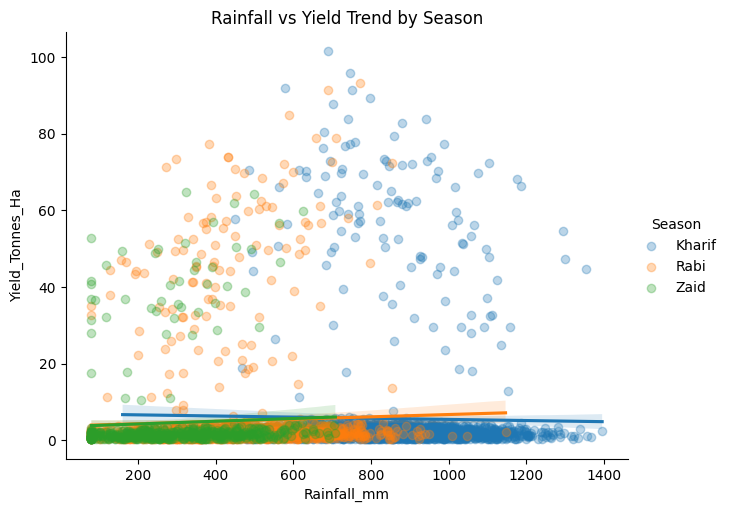

In [ ]:
sns.lmplot(data=data, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', height=5, aspect=1.3, scatter_kws={'alpha':0.3})
plt.title('Rainfall vs Yield Trend by Season')
plt.show()

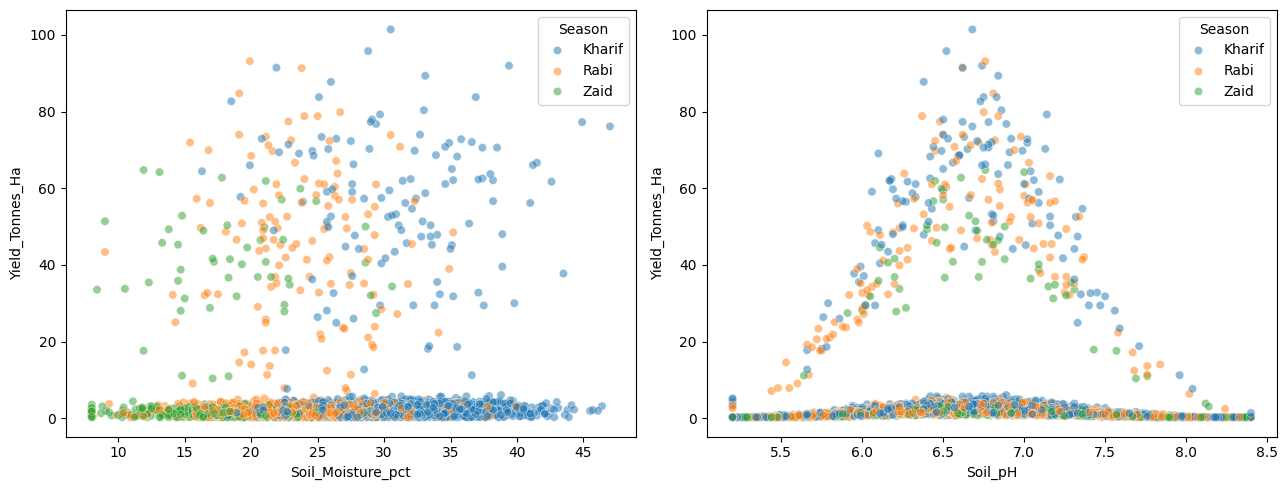

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=data, x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[0])
sns.scatterplot(data=data, x='Soil_pH', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

for col in env_cols:
    r, p = pearsonr(data[col].dropna(), data.loc[data[col].dropna().index, 'Yield_Tonnes_Ha'])
    print(f"{col}: r={r:.3f}, p={p:.4f} → {'Significant' if p<0.05 else 'Not significant'}")

Rainfall_mm: r=nan, p=nan → Not significant
Avg_Temperature_C: r=nan, p=nan → Not significant
Humidity_pct: r=nan, p=nan → Not significant
Sunlight_Hours_Day: r=nan, p=nan → Not significant
Soil_pH: r=nan, p=nan → Not significant
Soil_Moisture_pct: r=nan, p=nan → Not significant


In [ ]:
data['Profit_Margin_pct'] = (data['Profit_INR'] / data['Revenue_INR']) * 100
data.groupby('Season')['Profit_Margin_pct'].mean().round(2)

,Profit_Margin_pct
Season,
Kharif,-38.64
Rabi,-44.27
Zaid,-69.35


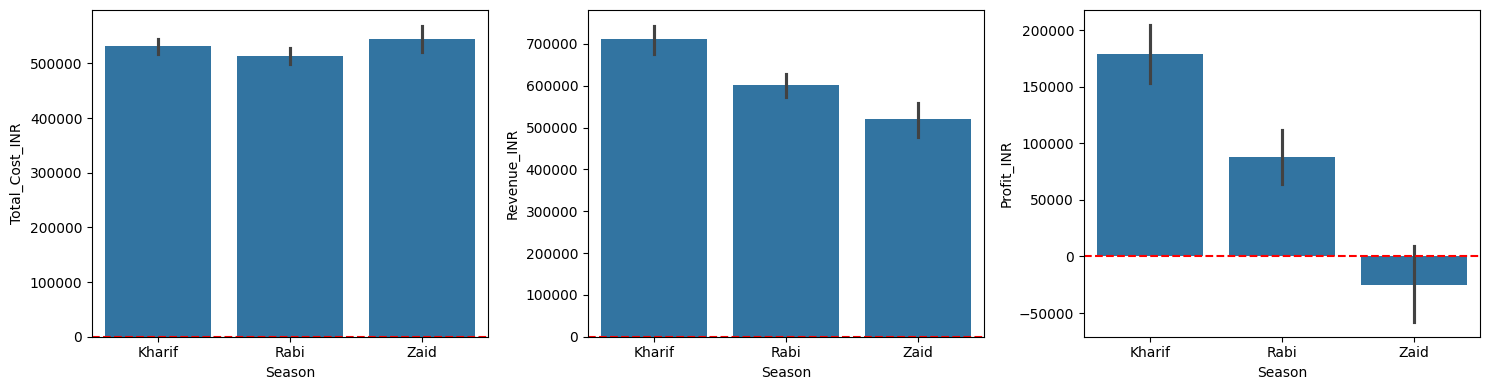

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.barplot(data=data, x='Season', y='Total_Cost_INR', estimator='mean', ax=axes[0])
sns.barplot(data=data, x='Season', y='Revenue_INR', estimator='mean', ax=axes[1])
sns.barplot(data=data, x='Season', y='Profit_INR', estimator='mean', ax=axes[2])
for ax in axes: ax.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


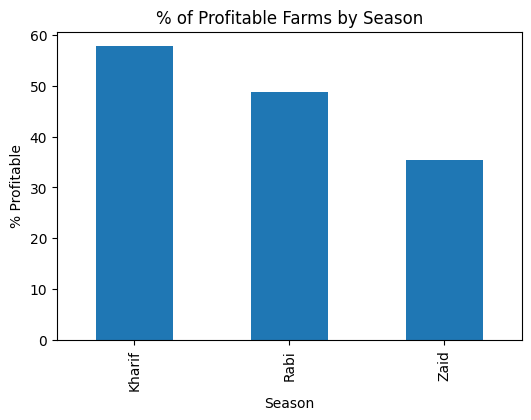

In [ ]:
data['Is_Profitable'] = data['Profit_INR'] > 0
profitability = data.groupby('Season')['Is_Profitable'].mean().round(3) * 100
print(profitability)

profitability.plot(kind='bar', figsize=(6,4), title='% of Profitable Farms by Season')
plt.ylabel('% Profitable')
plt.show()

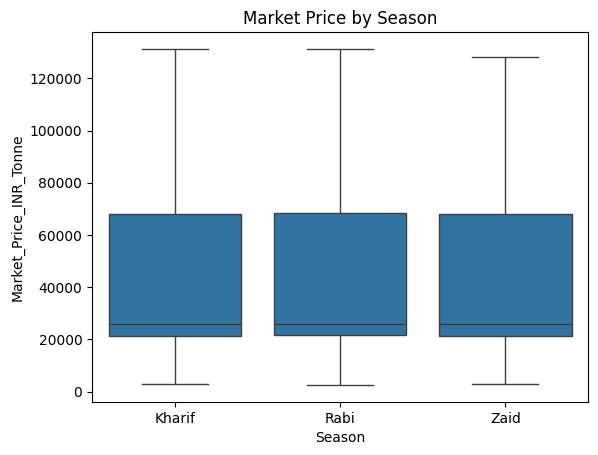

In [ ]:
sns.boxplot(data=data, x='Season', y='Market_Price_INR_Tonne')
plt.title('Market Price by Season')
plt.show()

In [ ]:
data.groupby('Season')[['Total_Cost_INR','Fertilizer_kg_ha','Pesticide_Litre_ha']].mean().round(2)

,Total_Cost_INR,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,531804.41,187.08,5.08
Rabi,513836.58,185.41,5.02
Zaid,543976.73,184.64,5.17


In [ ]:
season_state_yield = data.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
season_state_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


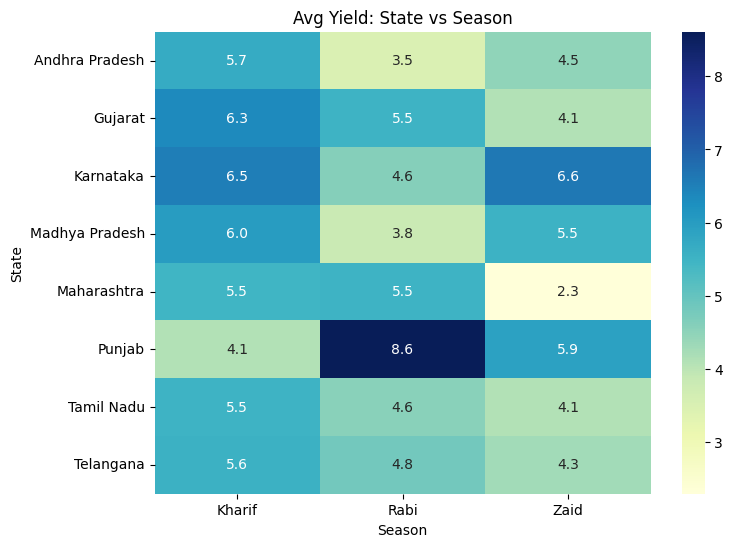

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(season_state_yield, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Avg Yield: State vs Season')
plt.show()

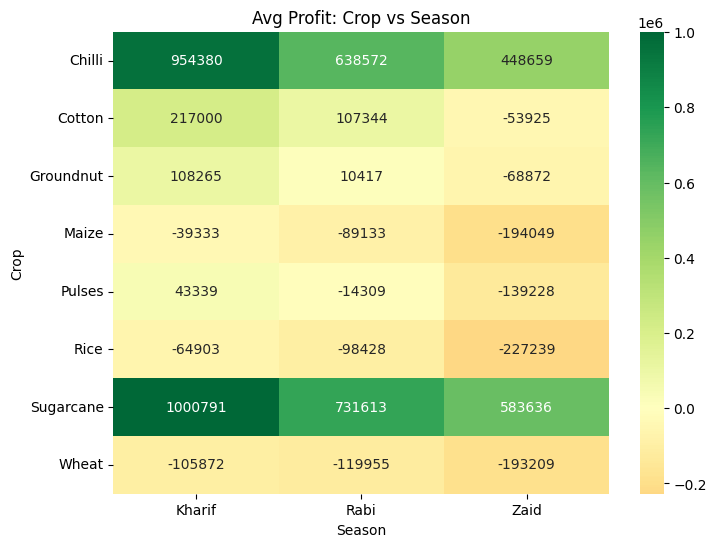

Kharif    8
Name: count, dtype: int64


In [ ]:
season_crop_profit = data.groupby(['Crop','Season'])['Profit_INR'].mean().unstack().round(0)
plt.figure(figsize=(8,6))
sns.heatmap(season_crop_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Avg Profit: Crop vs Season')
plt.show()

best_season_per_crop = season_crop_profit.idxmax(axis=1)
print(best_season_per_crop.value_counts())

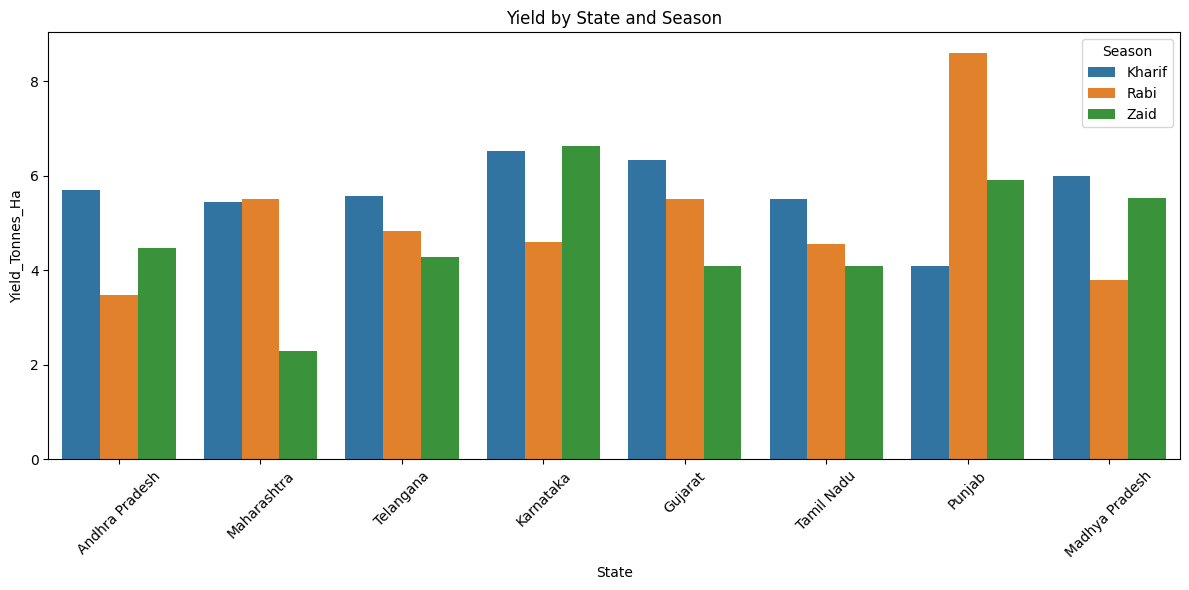

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=data, x='State', y='Yield_Tonnes_Ha', hue='Season', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title('Yield by State and Season')
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Yield_Tonnes_Ha ~ C(Season) * C(State)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Season),520.223353,2.0,1.460127,0.232332
C(State),887.161506,7.0,0.711435,0.662397
C(Season):C(State),4212.010957,14.0,1.688854,0.051051
Residual,702596.785172,3944.0,NaN,NaN


In [ ]:
def count_outliers(group, col):
    Q1, Q3 = group[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((group[col] < lower) | (group[col] > upper)).sum()

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3']:
    print(f"\n{col} outliers by season:")
    print(data.groupby('Season').apply(lambda g: count_outliers(g, col)))


Yield_Tonnes_Ha outliers by season:
Season
Kharif    121
Rabi      125
Zaid       49
dtype: int64

Profit_INR outliers by season:
Season
Kharif    184
Rabi      174
Zaid       64
dtype: int64

Water_Used_m3 outliers by season:
Season
Kharif    131
Rabi       99
Zaid       43
dtype: int64


/tmp/ipykernel_688/2906155551.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(data.groupby('Season').apply(lambda g: count_outliers(g, col)))
/tmp/ipykernel_688/2906155551.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(data.groupby('Season').apply(lambda g: count_outliers(g, col)))
/tmp/ipykernel_688/2906155551.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping co

In [ ]:
loss_farms = data[data['Profit_INR'] <= 0]
print(loss_farms.groupby('Season').size())
print((loss_farms.groupby('Season').size() / data.groupby('Season').size() * 100).round(1))

Season
Kharif    751
Rabi      832
Zaid      383
dtype: int64
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


In [ ]:
high_rain = data['Rainfall_mm'] > data['Rainfall_mm'].quantile(0.75)
low_yield = data['Yield_Tonnes_Ha'] < data['Yield_Tonnes_Ha'].quantile(0.25)
unusual = data[high_rain & low_yield]
print(unusual.groupby('Season').size())
unusual[['Season','Crop','Rainfall_mm','Yield_Tonnes_Ha','Disease_Pest_Risk_pct']].head(10)

Season
Kharif    214
Rabi        7
dtype: int64


,Season,Crop,Rainfall_mm,Yield_Tonnes_Ha,Disease_Pest_Risk_pct
1,Kharif,Maize,855.4,0.30,49.9
25,Kharif,Pulses,853.0,0.30,75.8
32,Kharif,Cotton,1066.8,0.64,67.7
64,Kharif,Pulses,1012.7,0.99,53.6
81,Kharif,Chilli,840.8,0.60,53.4
114,Kharif,Pulses,937.3,0.99,64.9
121,Kharif,Cotton,896.1,0.30,51.3
147,Kharif,Chilli,880.4,0.47,47.4
149,Kharif,Groundnut,878.5,0.72,70.8
153,Kharif,Rice,896.0,0.73,55.4


In [ ]:
data.groupby('Season')['Water_Used_m3'].describe()

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,6102.201237,5670.582696,139.0,2293.5,4469.0,7774.50,36156.0
Rabi,1627.0,5846.987093,5397.648066,128.0,2192.5,4292.0,7696.00,40902.0
Zaid,594.0,6419.893939,5734.619854,182.0,2539.5,4805.0,8155.25,34392.0


In [ ]:
for season in data['Season'].unique():
    sub = data[data['Season']==season]
    corr = sub['Disease_Pest_Risk_pct'].corr(sub['Yield_Tonnes_Ha'])
    print(f"{season}: correlation (risk vs yield) = {corr:.3f}")

Kharif: correlation (risk vs yield) = -0.027
Rabi: correlation (risk vs yield) = 0.015
Zaid: correlation (risk vs yield) = 0.040


In [ ]:
for season in data['Season'].unique():
    sub = data[data['Season']==season].sort_values('Profit_INR')
    print(f"\n--- {season}: Biggest Losses ---")
    print(sub[['Farm_ID','Crop','Profit_INR']].head(3))
    print(f"--- {season}: Biggest Profits ---")
    print(sub[['Farm_ID','Crop','Profit_INR']].tail(3))


--- Kharif: Biggest Losses ---
      Farm_ID   Crop  Profit_INR
2182  SF12183   Rice     -976860
3394  SF13395  Wheat     -963396
3090  SF13091  Maize     -890641
--- Kharif: Biggest Profits ---
      Farm_ID       Crop  Profit_INR
3425  SF13426  Sugarcane     3740099
626   SF10627     Chilli     4021850
2236  SF12237     Chilli     4345421

--- Rabi: Biggest Losses ---
      Farm_ID       Crop  Profit_INR
780   SF10781  Groundnut    -1019223
2210  SF12211      Wheat     -995195
3625  SF13626      Maize     -981050
--- Rabi: Biggest Profits ---
      Farm_ID       Crop  Profit_INR
1486  SF11487     Chilli     2883272
263   SF10264     Chilli     3159447
357   SF10358  Sugarcane     3378879

--- Zaid: Biggest Losses ---
      Farm_ID    Crop  Profit_INR
104   SF10105   Wheat     -965197
1311  SF11312    Rice     -902740
585   SF10586  Cotton     -895730
--- Zaid: Biggest Profits ---
      Farm_ID       Crop  Profit_INR
2008  SF12009     Chilli     2168427
1864  SF11865     Chilli     2

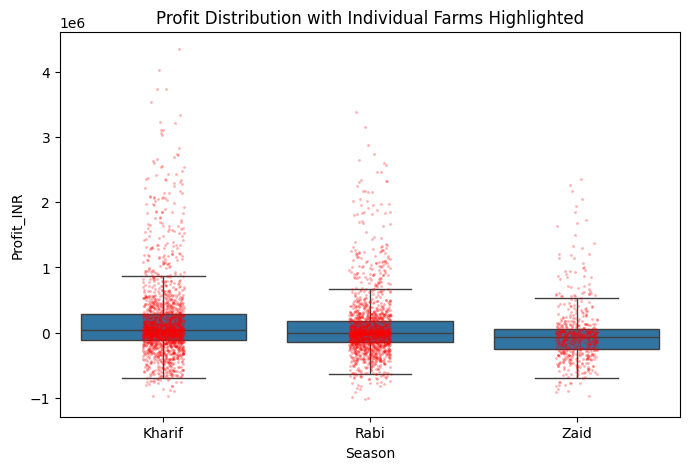

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Season', y='Profit_INR', showfliers=False)
sns.stripplot(data=data, x='Season', y='Profit_INR', color='red', alpha=0.3, size=2)
plt.title('Profit Distribution with Individual Farms Highlighted')
plt.show()

In [ ]:
best_combo = data.groupby(['Season','Crop'])['Profit_INR'].mean().sort_values(ascending=False).head(10)
best_combo

Season  Crop     
Kharif  Sugarcane    1.000791e+06
        Chilli       9.543804e+05
Rabi    Sugarcane    7.316129e+05
        Chilli       6.385725e+05
Zaid    Sugarcane    5.836358e+05
        Chilli       4.486591e+05
Kharif  Cotton       2.169995e+05
        Groundnut    1.082654e+05
Rabi    Cotton       1.073436e+05
Kharif  Pulses       4.333890e+04
Name: Profit_INR, dtype: float64